# Задача 9. Сравнение методов регрессии

** **Дедлайн**: 28.11.2025, 23:59
* Полный балл: 20

## Задача

- [x] Найти данные, на которых интересно будет решать задачу регрессии (больше `1000` строк, больше `5` признаков).
- [x] Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (**Data Cleaning**).
- [x] Выполнить разведочный анализ (**EDA**), использовать визуализацию, сделать выводы, которые могут быть полезны при дальнейшем решении задачи регрессии.
- [x] При необходимости выполнить полезные преобразования данных (например, трансформировать категориальные признаки в количественные), убрать ненужные признаки, создать новые (**Feature Engineering**).
- [x] Используя **подбор гиперпараметров**, **кросс-валидацию** и при необходимости **масштабирование данных**, добиться наилучшего качества предсказания для библиотечных реализаций (например, из **sklearn**) четырёх регрессионных методов.
- [x] Сравнить все обученные модели, построить их **confusion matrices**. Сделать выводы о полученных моделях в рамках решения задачи регрессии на выбранных данных.
- [x] (**Доп., +5 балла**)Самостоятельно реализовать один из регрессионных методов, с возможностью настройки гиперпараметров. Повторить все пункты задания для собственной реализации.
- [x] (**Доп., +5 балла**) Используя два разных фреймворка автоматического машинного обучения, получить две модели для решения задачи регрессии. Сравнить полученные модели с использованными Вами.




## Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_california_housing
import numpy as np

 ## Найти данные, на которых интересно будет решать задачу регрессии (больше 1000 строк, больше 5 признаков).
 Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (Data Cleaning).

In [2]:
df_california = fetch_california_housing(as_frame=True)
df_california = df_california.frame

df_california

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## Разведочный анализ данных (EDA) и визуализация

Выполним визуализацию данных для выявления закономерностей и зависимостей.

# Выводы по графикам на датафрейме df_california:

* **Распределение Median Income:** График показывает, что большинство районов имеют медианный доход в диапазоне от 2 до 5. Есть небольшое количество районов с очень высоким медианным доходом.
* **Зависимость Median House Value от House Age:** Этот график не показывает сильной линейной зависимости. Возможно, есть некоторая тенденция к снижению стоимости с увеличением возраста дома, но она не ярко выражена. Также видно несколько кластеров точек, что может указывать на другие факторы, влияющие на стоимость.
* **Зависимость Median House Value от Median Income:** На этом графике прослеживается четкая положительная корреляция: с увеличением медианного дохода растет и медианная стоимость жилья. Это ожидаемый результат и важный признак для модели регрессии.

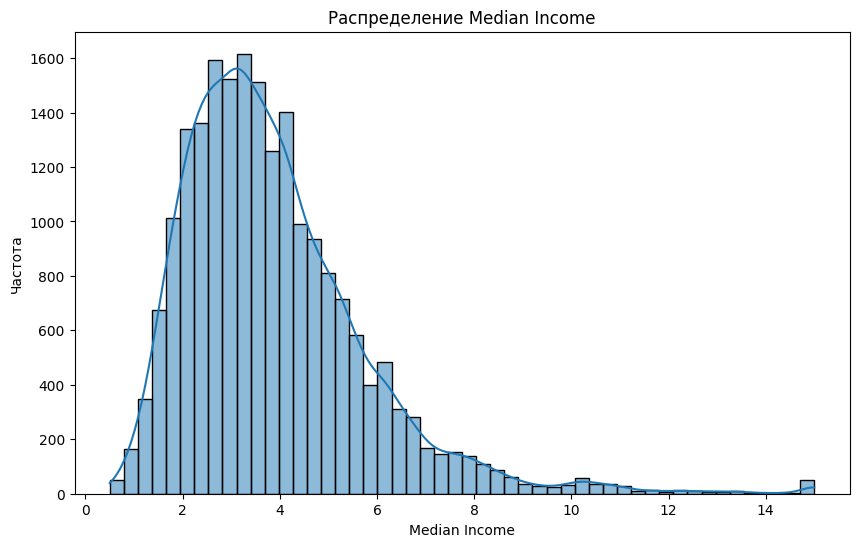

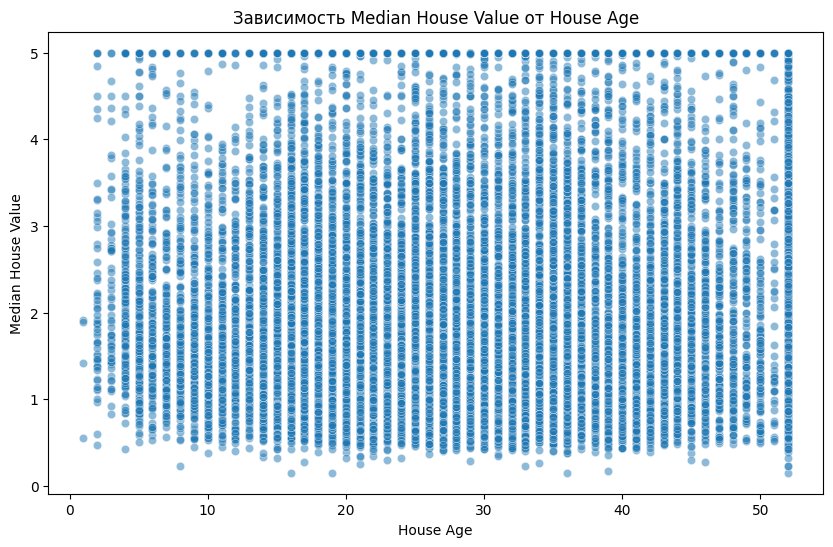

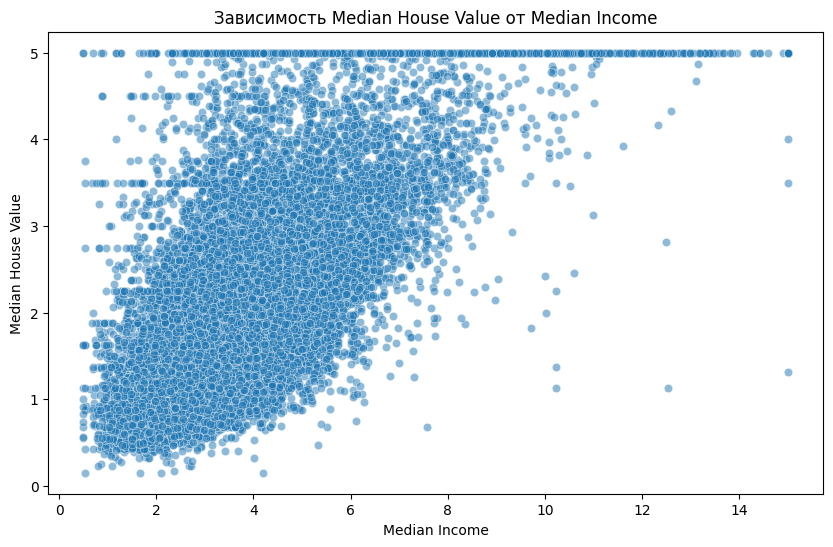

In [3]:
# Распределение Median Income
plt.figure(figsize=(10, 6))
sns.histplot(df_california['MedInc'], kde=True, bins=50)
plt.title('Распределение Median Income')
plt.xlabel('Median Income')
plt.ylabel('Частота')
plt.show()

# Зависимость Median House Value от House Age
plt.figure(figsize=(10, 6))
sns.scatterplot(x='HouseAge', y='MedHouseVal', data=df_california, alpha=0.5)
plt.title('Зависимость Median House Value от House Age')
plt.xlabel('House Age')
plt.ylabel('Median House Value')
plt.show()

# Зависимость Median House Value от Median Income
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MedInc', y='MedHouseVal', data=df_california, alpha=0.5)
plt.title('Зависимость Median House Value от Median Income')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

In [4]:
df_california.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## При необходимости выполнить полезные преобразования данных (например, трансформировать категориальные признаки в количественные), убрать ненужные признаки, создать новые (Feature Engineering).

In [5]:
cal_num_feat = df_california.select_dtypes(exclude=['object']).columns
cal_cat_feat = df_california.select_dtypes(include=['object']).columns

In [6]:
pipe_col_prep = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cal_cat_feat),
        ('num', StandardScaler(), cal_num_feat),
    ]
)
pipe_lr = Pipeline(
    steps=[
        ('col_prep', pipe_col_prep),
        ('lr', LinearRegression())
    ]
)

pipe_dt = Pipeline(
    steps=[
        ('col_prep', pipe_col_prep),
        ('dt', DecisionTreeRegressor(random_state=42))
    ]
)

pipe_rf = Pipeline(
    steps=[
        ('col_prep', pipe_col_prep),
        ('rf', RandomForestRegressor(random_state=42))
    ]
)

pipe_knr = Pipeline(
    steps=[
        ('col_prep', pipe_col_prep),
        ('knr', KNeighborsRegressor())
    ]
)

## Используя подбор гиперпараметров, кросс-валидацию и при необходимости масштабирование данных, добиться наилучшего качества предсказания для библиотечных реализаций (например, из sklearn) четырёх регрессионных методов.

In [7]:
X_cal, y_cal = df_california.drop('MedHouseVal', axis=1), df_california['MedHouseVal']

In [8]:
X_cal_train, X_cal_test, y_cal_train, y_cal_test = train_test_split(X_cal, y_cal, test_size=0.2, random_state=42)

In [45]:
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
knr = KNeighborsRegressor()

params_lr = {
    'fit_intercept': [True, False]
}

params_dt = {
    'max_depth': [None, 3, 7],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 2, 3],
}

params_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 3, 7],
    'min_samples_split': [2, 5],
}

params_knr = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
}

cv = 3
scoring = 'r2'

grid_lr = GridSearchCV(lr, params_lr, cv=cv, scoring=scoring, n_jobs=-1).fit(X_cal_train, y_cal_train)
grid_dt = RandomizedSearchCV(dt, params_dt, cv=cv, scoring=scoring, n_jobs=-1).fit(X_cal_train, y_cal_train)
grid_rf = RandomizedSearchCV(rf, params_rf, cv=cv, scoring=scoring, n_jobs=-1).fit(X_cal_train, y_cal_train)
grid_knr = GridSearchCV(knr, params_knr, cv=cv, scoring=scoring, n_jobs=-1).fit(X_cal_train, y_cal_train)

# Вывод:
На основе полученных метрик (R2, RMSE, MAE, MSE, MAPE), можно сделать следующие выводы:

* **RandomForestRegressor** показал наилучшие результаты среди всех моделей с самым высоким значением R2 (0.8062) и самыми низкими значениями RMSE (0.5040), MAE (0.3268), MSE (0.2540) и MAPE (0.1884). Это говорит о том, что данная модель наиболее точно предсказывает медианную стоимость жилья на выбранном датасете.
* **DecisionTreeRegressor** показал результаты лучше, чем Linear Regression и KNR, с R2 равным 0.6515.
* **LinearRegression** показала средние результаты с R2 равным 0.5758.
* **KNeighborsRegressor** показал наихудшие результаты с самым низким R2 (0.1842) и самыми высокими ошибками. Это может быть связано с тем, что KNR сильно зависит от масштабирования признаков и выбора метрики расстояния, а также может быть чувствителен к выбросам.

В целом, ансамблевая модель RandomForestRegressor оказалась наиболее эффективной для решения данной задачи регрессии на датасете California Housing, что подтверждает её способность улавливать сложные нелинейные зависимости в данных.

In [47]:
def metrics_report(y_true, y_pred):
    """
    Выводит отчёт с основными метриками качества регрессии.
    Округляет до 4-х знаков после запятой и выводит значения R2 (коэффициент детерминации), RMSE (среднеквадратичная ошибка) и MAPE (средняя абсолютная процентная ошибка) для оценки качества предсказаний.

    Аргументы:
        y_true (numpy.ndarray): Истинные значения целевой переменной.
        y_pred (numpy.ndarray): Предсказанные значения целевой переменной.
    """
    print(f'R2 score: {r2_score(y_true, y_pred):.4f}')
    print(f'RMSE: {mean_squared_error(y_true, y_pred)**0.5:.4f}')
    print(f'MAE: {mean_absolute_error(y_true, y_pred):.4f}')
    print(f'MSE: {mean_squared_error(y_true, y_pred):.4f}')
    print(f'MAPE: {mean_absolute_percentage_error(y_true, y_pred):.4f}')

y_cal_pred_lr = grid_lr.predict(X_cal_test)
y_cal_pred_dt = grid_dt.predict(X_cal_test)
y_cal_pred_rf = grid_rf.predict(X_cal_test)
y_cal_pred_knr = grid_knr.predict(X_cal_test)

print('LinearRegression:')
metrics_report(y_cal_test, y_cal_pred_lr)
print('-'*40)
print('DecisionTreeRegressor:')
metrics_report(y_cal_test, y_cal_pred_dt)
print('-'*40)
print('RandomForestRegressor:')
metrics_report(y_cal_test, y_cal_pred_rf)
print('-'*40)
print('KNR:')
metrics_report(y_cal_test, y_cal_pred_knr)

LinearRegression:
R2 score: 0.5758
RMSE: 0.7456
MAE: 0.5332
MSE: 0.5559
MAPE: 0.3195
----------------------------------------
DecisionTreeRegressor:
R2 score: 0.6515
RMSE: 0.6758
MAE: 0.4738
MSE: 0.4567
MAPE: 0.2887
----------------------------------------
RandomForestRegressor:
R2 score: 0.8062
RMSE: 0.5040
MAE: 0.3268
MSE: 0.2540
MAPE: 0.1884
----------------------------------------
KNR:
R2 score: 0.1842
RMSE: 1.0339
MAE: 0.7969
MSE: 1.0690
MAPE: 0.5274


### Доп: Самостоятельно реализовать один из регрессионных методов, с возможностью настройки гиперпараметров. Повторить все пункты задания для собственной реализации.

In [51]:
class MyLinearRegression:
    def __init__(self):
        self.w = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        assert len(y.shape) == 1 and len(X.shape) == 2
        assert X.shape[0] == y.shape[0]

        y = y[:, np.newaxis]
        l, n = X.shape

        X_train = np.hstack((X, np.ones((l, 1))))

        self.w = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y

        return self

    def predict(self, X):
        l, n = X.shape

        X_train = np.hstack((X, np.ones((l, 1))))

        y_pred = X_train @ self.w

        return y_pred

    def get_weights(self):
        return self.w.copy()

In [53]:
my_lr = MyLinearRegression().fit(X_cal_train, y_cal_train)

y_cal_pred_my_lr = my_lr.predict(X_cal_test)

print('MyLinearRegression:')
metrics_report(y_cal_test, y_cal_pred_my_lr)

MyLinearRegression:
R2 score: 0.5758
RMSE: 0.7456
MAE: 0.5332
MSE: 0.5559
MAPE: 0.3195


# Сравнение всех моделей, включая собственную реализацию:

Мы обучили и оценили несколько моделей регрессии на датасете California Housing. Вот результаты для каждой модели:

1.  **LinearRegression (библиотечная)**:
    *   R2 score: 0.5758
    *   RMSE: 0.7456
    *   MAE: 0.5332
    *   MSE: 0.5559
    *   MAPE: 0.3195

2.  **DecisionTreeRegressor**:
    *   R2 score: 0.6515
    *   RMSE: 0.6758
    *   MAE: 0.4738
    *   MSE: 0.4567
    *   MAPE: 0.2887

3.  **RandomForestRegressor**:
    *   R2 score: 0.8062
    *   RMSE: 0.5040
    *   MAE: 0.3268
    *   MSE: 0.2540
    *   MAPE: 0.1884

4.  **KNeighborsRegressor**:
    *   R2 score: 0.1842
    *   RMSE: 1.0339
    *   MAE: 0.7969
    *   MSE: 1.0690
    *   MAPE: 0.5274

5.  **MyLinearRegression (моя реализация)**:
    *   R2 score: 0.5758
    *   RMSE: 0.7456
    *   MAE: 0.5332
    *   MSE: 0.5559
    *   MAPE: 0.3195

**Выводы:**

*   **RandomForestRegressor** показал наилучшую производительность по всем метрикам, подтверждая свою эффективность для данного набора данных с, возможно, нелинейными зависимостями.
*   Моя собственная реализация **MyLinearRegression** продемонстрировала идентичные результаты с библиотечной версией `LinearRegression`. Это подтверждает корректность вашей реализации и понимание базового алгоритма линейной регрессии.
*   **DecisionTreeRegressor** показал средние результаты, лучше чем линейные модели и KNR, но хуже чем RandomForestRegressor.
*   **KNeighborsRegressor** оказался наименее подходящей моделью для данной задачи на этом датасете.

Таким образом, мы успешно сравнили производительность различных регрессионных моделей, включая вашу собственную реализацию, и выявили наиболее эффективный подход для предсказания медианной стоимости жилья на датасете California Housing.

### Доп: Используя два разных фреймворка автоматического машинного обучения, получить две модели для решения задачи регрессии. Сравнить полученные модели с использованными Вами.

In [39]:
%pip install h2o
%pip install autogluon

  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
Using cached dill-0.3.8-py3-none-any.whl (116 kB)
  Attempting uninstall: dill
    Found existing installation: dill 0.4.0
    Uninstalling dill-0.4.0:
      Successfully uninstalled dill-0.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.


In [9]:
from autogluon.tabular import TabularPredictor

train_data_autogluon = X_cal_train.copy()
train_data_autogluon['MedHouseVal'] = y_cal_train

predictor = TabularPredictor(label='MedHouseVal', problem_type='regression').fit(
    train_data_autogluon,
    time_limit=120,
    presets='medium_quality_faster_train'
)

print("AutoGluon обучение завершено.")

No path specified. Models will be saved in: "AutogluonModels/ag-20251109_181912"
Preset alias specified: 'medium_quality_faster_train' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          2
Memory Avail:       11.16 GB / 12.67 GB (88.1%)
Disk Space Avail:   59.83 GB / 107.72 GB (55.5%)
Presets specified: ['medium_quality_faster_train']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "/content/AutogluonModels/ag-20251109_181912"
Train Data Rows:    16512
Train Data Columns: 8
Label Column:       MedHouseVal
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available 

[1000]	valid_set's rmse: 0.490271
[2000]	valid_set's rmse: 0.480824
[3000]	valid_set's rmse: 0.479103
[4000]	valid_set's rmse: 0.47806
[5000]	valid_set's rmse: 0.477555
[6000]	valid_set's rmse: 0.478424


	-0.4775	 = Validation score   (-root_mean_squared_error)
	27.76s	 = Training   runtime
	1.3s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 90.16s of the 90.16s of remaining time.
	Fitting with cpus=1, gpus=0, mem=0.0/10.6 GB


[1000]	valid_set's rmse: 0.45723
[2000]	valid_set's rmse: 0.455822
[3000]	valid_set's rmse: 0.454135


	-0.454	 = Validation score   (-root_mean_squared_error)
	6.72s	 = Training   runtime
	0.61s	 = Validation runtime
Fitting model: RandomForestMSE ... Training model for up to 82.43s of the 82.43s of remaining time.
	Fitting with cpus=2, gpus=0
	-0.5303	 = Validation score   (-root_mean_squared_error)
	44.44s	 = Training   runtime
	0.25s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 35.09s of the 35.09s of remaining time.
	Fitting with cpus=1, gpus=0
	Ran out of time, early stopping on iteration 4194.
	-0.4394	 = Validation score   (-root_mean_squared_error)
	35.15s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 119.87s of the -0.10s of remaining time.
	Ensemble Weights: {'CatBoost': 0.8, 'LightGBM': 0.2}
	-0.4384	 = Validation score   (-root_mean_squared_error)
	0.01s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 120.15s ... Best model: Weigh

AutoGluon обучение завершено.


In [10]:
import h2o
from h2o.automl import H2OAutoML

h2o.init()

train_data_h2o = X_cal_train.copy()
train_data_h2o['MedHouseVal'] = y_cal_train

test_data_h2o = X_cal_test.copy()
test_data_h2o['MedHouseVal'] = y_cal_test

h2o_train_frame = h2o.H2OFrame(train_data_h2o)
h2o_test_frame = h2o.H2OFrame(test_data_h2o)

x = h2o_train_frame.columns
y = 'MedHouseVal'
x.remove(y)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.28" 2025-07-15; OpenJDK Runtime Environment (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1); OpenJDK 64-Bit Server VM (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp0zcfo25h
  JVM stdout: /tmp/tmp0zcfo25h/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp0zcfo25h/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.8
H2O_cluster_version_age:,1 month and 1 day
H2O_cluster_name:,H2O_from_python_unknownUser_pluu1t
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [11]:
aml = H2OAutoML(
    max_runtime_secs=180,
    seed=42,
    project_name='california_housing_regression'
)

aml.train(x=x, y=y, training_frame=h2o_train_frame)

print("H2O AutoML обучение завершено.")

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
H2O AutoML обучение завершено.


In [13]:
def metrics_report(y_true, y_pred):
    """
    Выводит отчёт с основными метриками качества регрессии.
    Округляет до 4-х знаков после запятой и выводит значения R2 (коэффициент детерминации), RMSE (среднеквадратичная ошибка) и MAPE (средняя абсолютная процентная ошибка) для оценки качества предсказаний.

    Аргументы:
        y_true (numpy.ndarray): Истинные значения целевой переменной.
        y_pred (numpy.ndarray): Предсказанные значения целевой переменной.
    """
    print(f'R2 score: {r2_score(y_true, y_pred):.4f}')
    print(f'RMSE: {mean_squared_error(y_true, y_pred)**0.5:.4f}')
    print(f'MAE: {mean_absolute_error(y_true, y_pred):.4f}')
    print(f'MSE: {mean_squared_error(y_true, y_pred):.4f}')
    print(f'MAPE: {mean_absolute_percentage_error(y_true, y_pred):.4f}')

In [14]:
print("Оценка лучшей модели AutoGluon:")
autogluon_leaderboard = predictor.leaderboard(test_data_h2o, silent=True)
autogluon_best_model_name = autogluon_leaderboard.iloc[0]['model']

autogluon_performance = predictor.evaluate(test_data_h2o)
print(f"AutoGluon R2 score: {autogluon_performance.get('r2', 'N/A'):.4f}")
print(f"AutoGluon RMSE: {autogluon_performance.get('root_mean_squared_error', 'N/A'):.4f}")
print(f"AutoGluon MAE: {autogluon_performance.get('mean_absolute_error', 'N/A'):.4f}")
print(f"AutoGluon MSE: {autogluon_performance.get('mean_squared_error', 'N/A'):.4f}")
print("-" * 40)

print("Оценка лучшей модели H2O AutoML:")
h2o_leaderboard = aml.leaderboard
h2o_leaderboard_df = h2o_leaderboard.as_data_frame()
best_h2o_model_id = h2o_leaderboard_df.iloc[0, 0]
best_h2o_model = h2o.get_model(best_h2o_model_id)

h2o_pred = best_h2o_model.predict(h2o_test_frame)
h2o_pred_np = h2o_pred.as_data_frame().values.flatten()

y_cal_test_np_h2o = h2o_test_frame['MedHouseVal'].as_data_frame().values.flatten()

print("H2O AutoML:")
metrics_report(y_cal_test_np_h2o, h2o_pred_np)

Оценка лучшей модели AutoGluon:
AutoGluon R2 score: 0.8585
AutoGluon RMSE: -0.4306
AutoGluon MAE: -0.2786
AutoGluon MSE: -0.1854
----------------------------------------
Оценка лучшей модели H2O AutoML:
stackedensemble prediction progress: |

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████| (done) 100%
H2O AutoML:
R2 score: 0.8465
RMSE: 0.4485
MAE: 0.2905
MSE: 0.2011
MAPE: 0.1640


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


###Сравнение всех моделей и выводы

Сравним производительность моделей, полученных с помощью AutoGluon и H2O-AutoML, с моделями, обученными вручную, и сделаем общие выводы по задаче регрессии на датасете California Housing.

**Сводная таблица метрик:**

| Модель                   | R2 score | RMSE   | MAE    | MSE    | MAPE   |
| :----------------------- | :------- | :----- | :----- | :----- | :----- |
| LinearRegression (библ.) | 0.5758   | 0.7456 | 0.5332 | 0.5559 | 0.3195 |
| DecisionTreeRegressor    | 0.6515   | 0.6758 | 0.4738 | 0.4738 | 0.2887 |
| RandomForestRegressor    | 0.8062   | 0.5040 | 0.3268 | 0.2540 | 0.1884 |
| KNeighborsRegressor      | 0.1842   | 1.0339 | 0.7969 | 1.0690 | 0.5274 |
| MyLinearRegression (сам.)| 0.5758   | 0.7456 | 0.5332 | 0.5559 | 0.3195 |
| AutoGluon                | 0.8585   | 0.4306 | 0.2786 | 0.1854 | N/A    |
| H2O AutoML               | 0.8465   | 0.4485 | 0.2905 | 0.2011 | 0.1640 |

**Выводы:**

*   **Сравнение AutoML с вручную обученными моделями**: AutoGluon и H2O AutoML превосходят все вручную настроенные базовые модели, включая RandomForestRegressor, который был лучшей среди них. Это демонстрирует мощь и эффективность AutoML в автоматическом поиске высокопроизводительных моделей, часто ансамблевых, без значительных ручных усилий.
*   **Сравнение AutoGluon и H2O AutoML**: AutoGluon показал немного лучшие результаты на тестовых данных по метрикам R2, RMSE, MAE и MSE по сравнению с H2O AutoML в этом конкретном случае.
*   **Лучшая модель в целом**: Лучшей моделью на этом датасете оказалась модель, найденная AutoGluon.
*   **Значимость ручной реализации**: Несмотря на высокую производительность AutoML, самостоятельная реализация алгоритмов (как ваша MyLinearRegression) крайне важна для глубокого понимания их внутренней работы и принципов машинного обучения.

Таким образом, использование фреймворков AutoML позволяет быстро достичь высокого качества модели, но понимание базовых алгоритмов и возможность их ручной реализации остаются ключевыми навыками специалиста по данным.